# 04. Robustness Analysis

This notebook evaluates whether the trained RF classifier can still identify LLM authors
when models are instructed to write in different tones (formal, casual, human-mimic).

1. Setup & Prompt Loading
2. Corpus Generation
3. Feature Extraction
4. Neutral Baseline
5. Per-Tone Evaluation
6. Detailed Breakdown


In [1]:
import sys
sys.path.insert(0, '..')

import json
import warnings


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from src.generation import LLMGenerator
from src.analysis import StylometricAnalyzer, AuthorshipClassifier, CORE_FEATURES

warnings.filterwarnings('ignore')

## 1. Setup & Prompt Loading

In [3]:
generator = LLMGenerator('../config.yaml')
generator.setup_providers()

all_prompts = generator.load_prompts('../data/prompts/prompts.yaml')

with open('../data/prompts/robustness_prompts.yaml') as f:
    rob_config = yaml.safe_load(f)

tone_modifiers = rob_config['tone_modifiers']
base_ids = rob_config['base_prompt_ids']

base_prompts = [p for p in all_prompts if p['id'] in base_ids]
assert len(base_prompts) == 8, f'Expected 8 base prompts, got {len(base_prompts)}'

print(f'Base prompts: {[p["id"] for p in base_prompts]}')
print(f'Tones: {list(tone_modifiers.keys())}')
print(f'Models: {[m["name"] for m in generator.config["models"]]}')

Base prompts: ['narr_01', 'narr_05', 'arg_01', 'arg_09', 'dial_02', 'dial_09', 'desc_01', 'desc_05']
Tones: ['formal', 'casual', 'human_mimic']
Models: ['gpt-4-turbo', 'llama3', 'mistral']


## 2. Corpus Generation

Generate 144 tone-modified texts: 8 prompts × 3 tones × 3 models × 2 runs.

Saves incrementally to `data/raw/corpus_robustness.json` and supports resume.
Re-running this cell safely skips already-generated entries.

In [ ]:
results = generator.generate_tone_corpus(
    prompts=base_prompts,
    tone_modifiers=tone_modifiers,
    models=['gpt-4-turbo'],
    output_path='../data/raw/corpus_robustness.json',
    num_runs=2,
    api_delay=1.0,
)

corpus = [r for r in results if 'error' not in r]

In [ ]:
results = generator.generate_tone_corpus(
    prompts=base_prompts,
    tone_modifiers=tone_modifiers,
    models=['llama3', 'mistral'],
    output_path='../data/raw/corpus_robustness.json',
    num_runs=2,
    api_delay=1.0,
)

corpus = [r for r in results if 'error' not in r]

In [5]:
successful = [e for e in corpus if 'error' not in e]
df_check = pd.DataFrame(successful)
print(f'Total entries: {len(df_check)}  (expected: 144)')
print(f'\nBreakdown by tone × model:')
print(df_check.groupby(['tone', 'model']).size().unstack(fill_value=0))

Total entries: 144  (expected: 144)

Breakdown by tone × model:
model        gpt-4-turbo  llama3  mistral
tone                                     
casual                16      16       16
formal                16      16       16
human_mimic           16      16       16


## 3. Feature Extraction

Extract 19 stylometric features from the tone-modified corpus, then add 48 neutral
baseline texts (runs 1–2 only) from the existing feature matrix for a balanced design
(48 texts per condition).

In [6]:
analyzer = StylometricAnalyzer()

with open('../data/raw/corpus_robustness.json') as f:
    rob_corpus = [e for e in json.load(f) if 'error' not in e]

texts = [e['generated_text'] for e in rob_corpus]
labels = [e['model'] for e in rob_corpus]
genres = [e['genre'] for e in rob_corpus]
prompt_ids = [e['prompt_id'] for e in rob_corpus]
run_ids = [e['run'] for e in rob_corpus]

df_robustness = analyzer.analyze_corpus(
    texts=texts, labels=labels, genres=genres,
    prompt_ids=prompt_ids, runs=run_ids,
)
df_robustness['tone'] = [e['tone'] for e in rob_corpus]
print(f'Tone-modified features: {df_robustness.shape}')

# Add neutral baseline (runs 1-2 only for balance)
df_existing = pd.read_csv('../data/processed/features.csv')
base_ids = ['narr_01', 'narr_05', 'arg_01', 'arg_09',
            'dial_02', 'dial_09', 'desc_01', 'desc_05']
df_neutral = df_existing[
    (df_existing['prompt_id'].isin(base_ids)) &
    (df_existing['run'].isin([1, 2]))
].copy()
df_neutral['tone'] = 'neutral'

df_all = pd.concat([df_neutral, df_robustness], ignore_index=True)
print(f'Neutral baseline: {len(df_neutral)} rows')
print(f'Combined dataset: {len(df_all)} rows  (expected: 192)')
print(f'\nPer-condition counts:')
print(df_all.groupby('tone').size())

df_all.to_csv('../data/processed/features_robustness.csv', index=False)
print('\nSaved to ../data/processed/features_robustness.csv')

Tone-modified features: (144, 24)
Neutral baseline: 48 rows
Combined dataset: 192 rows  (expected: 192)

Per-condition counts:
tone
casual         48
formal         48
human_mimic    48
neutral        48
dtype: int64

Saved to ../data/processed/features_robustness.csv


## 4. Neutral Baseline

Load the trained RF classifier (from notebook 03) and predict on the full robustness set.
The neutral-condition accuracy is **in-sample** (training prompts) and serves as the
robustness baseline — all tone comparisons are against it, not against the held-out 0.75.

In [7]:
if len(df_all) == 0:
    df_all = pd.read_csv('../data/processed/features_robustness.csv')

clf = AuthorshipClassifier.load('../data/processed/classifier_rf.joblib')

X_all = df_all[CORE_FEATURES]
df_all['predicted'] = clf.predict(X_all)
df_all['correct'] = df_all['predicted'] == df_all['label']

neutral = df_all[df_all['tone'] == 'neutral']
neutral_acc = accuracy_score(neutral['label'], neutral['predicted'])
neutral_f1 = f1_score(neutral['label'], neutral['predicted'], average='macro')
print(f'Neutral (in-sample) baseline:  accuracy={neutral_acc:.3f},  F1={neutral_f1:.3f}')


Neutral (in-sample) baseline:  accuracy=1.000,  F1=1.000


## 5. Per-Tone Evaluation

In [8]:
tone_order = ['neutral', 'formal', 'casual', 'human_mimic']

results = []
for tone in tone_order:
    subset = df_all[df_all['tone'] == tone]
    acc = accuracy_score(subset['label'], subset['predicted'])
    f1 = f1_score(subset['label'], subset['predicted'], average='macro')
    results.append({'tone': tone, 'accuracy': acc, 'f1_macro': f1, 'n': len(subset)})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

       tone  accuracy  f1_macro  n
    neutral  1.000000  1.000000 48
     formal  0.645833  0.652468 48
     casual  0.458333  0.387395 48
human_mimic  0.604167  0.572441 48


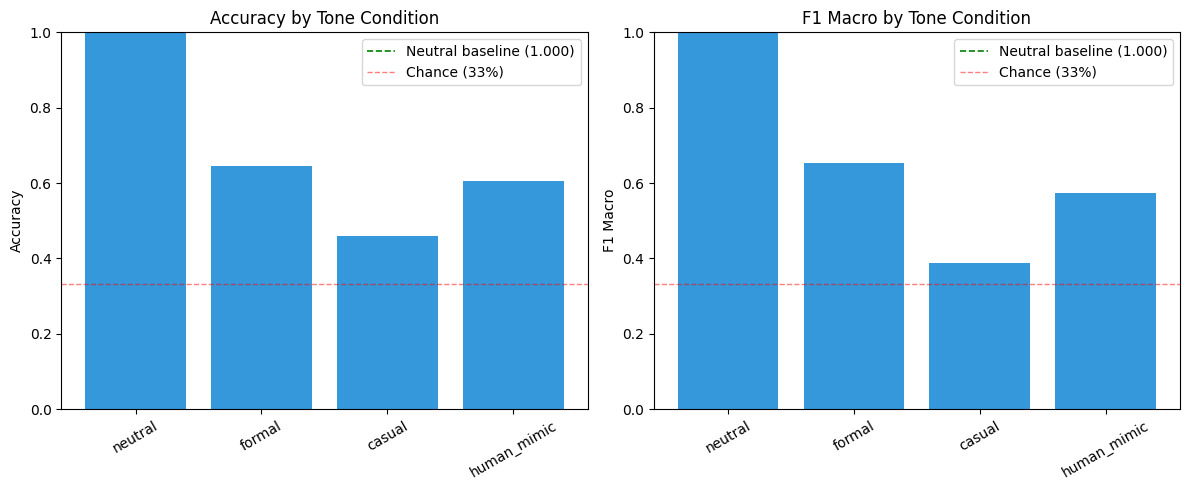

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, metric in enumerate(['accuracy', 'f1_macro']):
    ax = axes[i]
    ax.bar(df_results['tone'], df_results[metric], color='#3498db')
    ax.axhline(df_results.loc[0, metric], color='green', linestyle='--',linewidth=1.2,
               label=f'Neutral baseline ({df_results.loc[0, metric]:.3f})')
    ax.axhline(1/3, color='red', linestyle='--', linewidth=1, alpha=0.5,label='Chance (33%)')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} by Tone Condition')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Detailed Breakdown

In [ ]:
crosstab = pd.crosstab(
    df_all['label'], df_all['tone'],
    values=df_all['correct'], aggfunc='mean'
)[tone_order]
print('Per-model accuracy by tone:')
print(crosstab.round(3).to_string())

Per-model accuracy by tone:
tone         neutral  formal  casual  human_mimic
label                                            
gpt-4-turbo      1.0   0.750   0.375        0.500
llama3           1.0   0.750   0.938        1.000
mistral          1.0   0.438   0.062        0.312


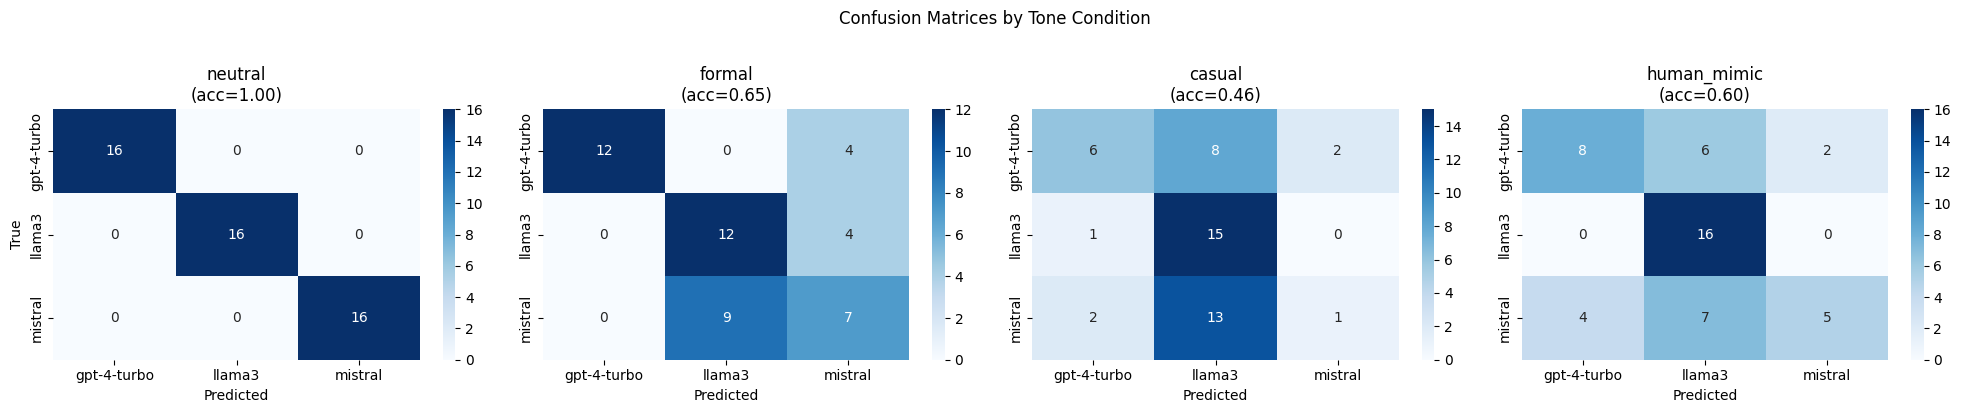

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_labels = sorted(df_all['label'].unique())

for ax, tone in zip(axes, tone_order):
    subset = df_all[df_all['tone'] == tone]
    cm = confusion_matrix(subset['label'], subset['predicted'], labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    acc = accuracy_score(subset['label'], subset['predicted'])
    ax.set_title(f'{tone}\n(acc={acc:.2f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax == axes[0] else '')

plt.suptitle('Confusion Matrices by Tone Condition', y=1.02)
plt.tight_layout()
plt.show()